# ListenBrainz Star Schema Prediction Model Notebook

This notebook uses the **dbt star schema tables** created from the ListenBrainz dataset to build a simple machine learning enhancement.

## Objective

Use the star schema output to predict whether a user is likely to repeatedly listen to a track.

## Source star schema tables

- `fact_listening_events`
- `dim_user`
- `dim_track`
- `dim_artist`
- `dim_album`
- `dim_date`
- `dim_time`

## ML target

`repeated_listen`

- `1` = user listened to a track more than once
- `0` = user listened to a track once only

This supports a future **music recommendation model**.


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install required packages

In [11]:
!pip install google-cloud-bigquery pandas db-dtypes scikit-learn matplotlib


## 2. Configure BigQuery connection

Update the service account key path to match your computer.


In [12]:
import os

# Change this path to your actual service account JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"/content/drive/MyDrive/keys/my-project-sssint1-7e02e9078e06.json"

PROJECT_ID = "my-project-sssint1"
DATASET = "listenbrainz_gcp"

print("Project:", PROJECT_ID)
print("Dataset:", DATASET)


Project: my-project-sssint1
Dataset: listenbrainz_gcp


## 3. Load ML dataset from star schema

This query joins the fact table with dimension tables to create a machine learning dataset.

The query uses a limit to keep the notebook fast. Increase the limit after testing.


In [13]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT
    u.user_name,
    t.track_id,
    t.track_name,
    t.artist_name AS track_artist_name,
    ar.artist_id,
    ar.artist_name,
    al.album_id,
    al.release_name,
    d.day_of_week,
    d.is_weekend,
    d.month,
    d.year,
    tm.hour,
    tm.time_period,
    COUNT(*) AS listen_count
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_user` u
    ON f.user_id = u.user_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_track` t
    ON f.track_id = t.track_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_artist` ar
    ON f.artist_id = ar.artist_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_album` al
    ON f.album_id = al.album_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_date` d
    ON f.date_id = d.date_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_time` tm
    ON f.time_id = tm.time_id

WHERE u.user_name IS NOT NULL
  AND t.track_id IS NOT NULL
  AND t.track_name IS NOT NULL
  AND ar.artist_name IS NOT NULL

GROUP BY
    u.user_name,
    t.track_id,
    t.track_name,
    track_artist_name,
    ar.artist_id,
    ar.artist_name,
    al.album_id,
    al.release_name,
    d.day_of_week,
    d.is_weekend,
    d.month,
    d.year,
    tm.hour,
    tm.time_period

LIMIT 50000
"""

model_df = client.query(query).to_dataframe()
model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,month,year,hour,time_period,listen_count
0,jesus2099,93724d87d6fcadab85b9a94586f73535,打ち上げ花火,榎本くるみ,0f6a22da68e1ba768513a763ab2bc409,榎本くるみ,b58c78030380b5204682c1c061f9b22d,,Monday,False,2,2008,0,Night,1
1,weedwums,f309ba1c0368c434e4a3c9940957b866,Crush,Pendulum,d24c9dfcc8952802fa1919e6c398d26b,Pendulum,bd783a6966475ac7b251588ef80fe6c5,,Monday,False,3,2017,0,Night,4
2,organelas,34e02abe23b85cd1164db035319f2a00,Pony,Annette Peacock,d22e2947a4f65624758779e0d91c0080,Annette Peacock,13670ba2375a39666b43a7810b67eaf6,I'm the One,Thursday,False,5,2008,0,Night,1
3,elionaz,4f974e429a98fdf61b3f77fcc6460837,Afuera,Enrique Bunbury,47fb648ead68cbf7db6d48c251f6f22f,Enrique Bunbury,85a68e25e4b082abe61f794d5bcd41c1,,Saturday,True,3,2011,0,Night,36
4,gulogulogulo,6f44179f1c5788a75e388622d7c8ca37,Walk on By,Isaac Hayes,a96ccac14835c35bf428704acad321a8,Isaac Hayes,08d94803acd70e41eed50b9df0c69deb,,Sunday,True,5,2014,0,Night,1


## 4. Basic checks

In [14]:
print("Rows:", len(model_df))
print("Unique users:", model_df["user_name"].nunique())
print("Unique tracks:", model_df["track_id"].nunique())
print("Unique artists:", model_df["artist_name"].nunique())
print("Columns:", model_df.columns.tolist())

model_df.isnull().sum()


Rows: 50000
Unique users: 1918
Unique tracks: 42817
Unique artists: 12197
Columns: ['user_name', 'track_id', 'track_name', 'track_artist_name', 'artist_id', 'artist_name', 'album_id', 'release_name', 'day_of_week', 'is_weekend', 'month', 'year', 'hour', 'time_period', 'listen_count']


,0
user_name,0
track_id,0
track_name,0
track_artist_name,0
artist_id,0
artist_name,0
album_id,0
release_name,0
day_of_week,0
is_weekend,0


## 5. Create target variable

The model predicts whether the user repeatedly listened to the same track.


In [15]:
model_df["repeated_listen"] = (model_df["listen_count"] > 1).astype(int)

model_df["repeated_listen"].value_counts()


,count
repeated_listen,
1,37593
0,12407


## 6. Create popularity and activity features

These features are created from the star schema ML dataset.


In [16]:
track_popularity = (
    model_df.groupby("track_id")["listen_count"]
    .sum()
    .reset_index(name="track_total_listens")
)

artist_popularity = (
    model_df.groupby("artist_id")["listen_count"]
    .sum()
    .reset_index(name="artist_total_listens")
)

user_activity = (
    model_df.groupby("user_name")["listen_count"]
    .sum()
    .reset_index(name="user_total_listens")
)

model_df = model_df.merge(track_popularity, on="track_id", how="left")
model_df = model_df.merge(artist_popularity, on="artist_id", how="left")
model_df = model_df.merge(user_activity, on="user_name", how="left")

model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,month,year,hour,time_period,listen_count,repeated_listen,track_total_listens,artist_total_listens,user_total_listens
0,jesus2099,93724d87d6fcadab85b9a94586f73535,打ち上げ花火,榎本くるみ,0f6a22da68e1ba768513a763ab2bc409,榎本くるみ,b58c78030380b5204682c1c061f9b22d,,Monday,False,2,2008,0,Night,1,0,1,1,533
1,weedwums,f309ba1c0368c434e4a3c9940957b866,Crush,Pendulum,d24c9dfcc8952802fa1919e6c398d26b,Pendulum,bd783a6966475ac7b251588ef80fe6c5,,Monday,False,3,2017,0,Night,4,1,12,1355,11316
2,organelas,34e02abe23b85cd1164db035319f2a00,Pony,Annette Peacock,d22e2947a4f65624758779e0d91c0080,Annette Peacock,13670ba2375a39666b43a7810b67eaf6,I'm the One,Thursday,False,5,2008,0,Night,1,0,1,1,8281
3,elionaz,4f974e429a98fdf61b3f77fcc6460837,Afuera,Enrique Bunbury,47fb648ead68cbf7db6d48c251f6f22f,Enrique Bunbury,85a68e25e4b082abe61f794d5bcd41c1,,Saturday,True,3,2011,0,Night,36,1,36,36,13947
4,gulogulogulo,6f44179f1c5788a75e388622d7c8ca37,Walk on By,Isaac Hayes,a96ccac14835c35bf428704acad321a8,Isaac Hayes,08d94803acd70e41eed50b9df0c69deb,,Sunday,True,5,2014,0,Night,1,0,1,530,22438


## 7. Encode categorical variables

In [17]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["user_name", "track_id", "artist_id", "day_of_week", "time_period"]:
    encoder = LabelEncoder()
    model_df[col] = model_df[col].astype(str)
    model_df[col + "_encoded"] = encoder.fit_transform(model_df[col])
    encoders[col] = encoder

model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,...,listen_count,repeated_listen,track_total_listens,artist_total_listens,user_total_listens,user_name_encoded,track_id_encoded,artist_id_encoded,day_of_week_encoded,time_period_encoded
0,jesus2099,93724d87d6fcadab85b9a94586f73535,打ち上げ花火,榎本くるみ,0f6a22da68e1ba768513a763ab2bc409,榎本くるみ,b58c78030380b5204682c1c061f9b22d,,Monday,False,...,1,0,1,1,533,1144,24440,865,1,3
1,weedwums,f309ba1c0368c434e4a3c9940957b866,Crush,Pendulum,d24c9dfcc8952802fa1919e6c398d26b,Pendulum,bd783a6966475ac7b251588ef80fe6c5,,Monday,False,...,4,1,12,1355,11316,1857,40625,12041,1,3
2,organelas,34e02abe23b85cd1164db035319f2a00,Pony,Annette Peacock,d22e2947a4f65624758779e0d91c0080,Annette Peacock,13670ba2375a39666b43a7810b67eaf6,I'm the One,Thursday,False,...,1,0,1,1,8281,1481,8734,12035,4,3
3,elionaz,4f974e429a98fdf61b3f77fcc6460837,Afuera,Enrique Bunbury,47fb648ead68cbf7db6d48c251f6f22f,Enrique Bunbury,85a68e25e4b082abe61f794d5bcd41c1,,Saturday,True,...,36,1,36,36,13947,927,13184,4080,2,3
4,gulogulogulo,6f44179f1c5788a75e388622d7c8ca37,Walk on By,Isaac Hayes,a96ccac14835c35bf428704acad321a8,Isaac Hayes,08d94803acd70e41eed50b9df0c69deb,,Sunday,True,...,1,0,1,530,22438,1032,18496,9657,3,3


## 8. Prepare features and train/test split

In [18]:
from sklearn.model_selection import train_test_split

features = [
    "user_name_encoded",
    "track_id_encoded",
    "artist_id_encoded",
    "day_of_week_encoded",
    "time_period_encoded",
    "is_weekend",
    "month",
    "hour",
    "track_total_listens",
    "artist_total_listens",
    "user_total_listens"
]

# Convert boolean to integer
model_df["is_weekend"] = model_df["is_weekend"].astype(int)

X = model_df[features]
y = model_df["repeated_listen"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))


Train rows: 40000
Test rows: 10000


## 9. Baseline model: Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred, zero_division=0))
print("Recall:", recall_score(y_test, log_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, log_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, log_pred, zero_division=0))


Logistic Regression Results
Accuracy: 0.973
Precision: 0.9794946421484323
Recall: 0.9847054129538503
F1 Score: 0.9820931157978512

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2481
           1       0.98      0.98      0.98      7519

    accuracy                           0.97     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.97      0.97      0.97     10000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 10. Improved model: Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, rf_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))


Random Forest Results
Accuracy: 0.9842
Precision: 0.9884538818845389
Recall: 0.9905572549541163
F1 Score: 0.989504450644347

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2481
           1       0.99      0.99      0.99      7519

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 11. Feature importance

In [22]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance


,feature,importance
8,track_total_listens,0.831063
9,artist_total_listens,0.150157
10,user_total_listens,0.005052
1,track_id_encoded,0.003498
2,artist_id_encoded,0.002768
0,user_name_encoded,0.002705
7,hour,0.001599
6,month,0.001234
3,day_of_week_encoded,0.000995
4,time_period_encoded,0.000659


## 12. Plot feature importance

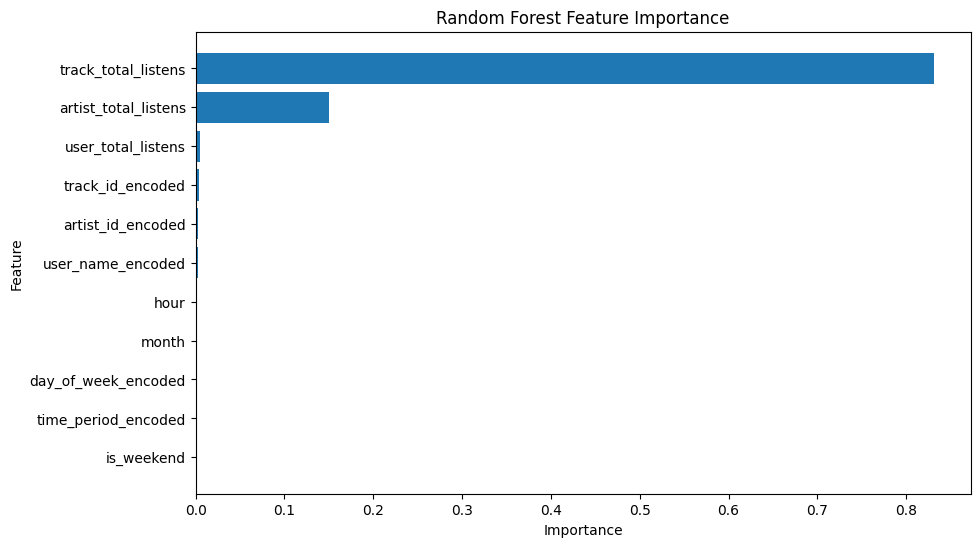

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()


## 13. Simple recommendation function

This recommends tracks that a selected user has not listened to yet, ranked by popularity.


In [24]:
def recommend_tracks_for_user(user_name, top_n=10):
    if user_name not in model_df["user_name"].values:
        return f"User {user_name} not found in sample data."

    listened_tracks = set(
        model_df.loc[model_df["user_name"] == user_name, "track_id"]
    )

    candidates = (
        model_df[~model_df["track_id"].isin(listened_tracks)]
        [["track_id", "track_name", "artist_name", "release_name", "track_total_listens", "artist_total_listens"]]
        .drop_duplicates()
        .sort_values(["track_total_listens", "artist_total_listens"], ascending=False)
        .head(top_n)
    )

    return candidates

sample_user = model_df["user_name"].iloc[0]
print("Sample user:", sample_user)
recommend_tracks_for_user(sample_user, top_n=10)


Sample user: jesus2099


,track_id,track_name,artist_name,release_name,track_total_listens,artist_total_listens
32396,fb75e0bb95563bb0417792192310395e,Black,Pearl Jam,Ten,135424,369930
24404,fb75e0bb95563bb0417792192310395e,Black,Pearl Jam,,135424,239392
32438,fb75e0bb95563bb0417792192310395e,Black,Pearl Jam,,135424,143692
1019,d1aa61e681da96b5bd9e8ac810d8c804,Better Man,Pearl Jam,Vitalogy,112500,369930
32437,d1aa61e681da96b5bd9e8ac810d8c804,Better Man,Pearl Jam,,112500,369930
17700,d1aa61e681da96b5bd9e8ac810d8c804,Better Man,Pearl Jam,,112500,239392
22101,fb29564f8622065b703c7bba805322d7,Even Flow,Pearl Jam,,106722,239392
45623,fb29564f8622065b703c7bba805322d7,Even Flow,Pearl Jam,,106722,143692
3272,8914315e9dba8e45a073e5ffae2d4f6d,Bohemian Rhapsody,Queen,,95139,92988
49067,8914315e9dba8e45a073e5ffae2d4f6d,Bohemian Rhapsody,Queen,A Night at the Opera,95139,74309


## 14. Predict repeat-listen probability

This gives a probability score for repeated listening.


In [27]:
if hasattr(rf_model, "predict_proba"):
    probabilities = rf_model.predict_proba(X_test)[:, 1]

    prediction_results = X_test.copy()
    prediction_results["actual_repeated_listen"] = y_test.values
    prediction_results["predicted_repeated_probability"] = probabilities

    prediction_results.sort_values(
        "predicted_repeated_probability",
        ascending=False
    ).head(10)


## 15. Report explanation

The machine learning enhancement uses the dbt star schema instead of the raw dataset. The central `fact_listening_events` table provides listening events, while dimension tables provide descriptive features such as user, track, artist, release, date, and time. These tables are joined to create a machine learning dataset. The model predicts whether a user is likely to repeatedly listen to a track. Logistic Regression is used as a baseline model, while Random Forest is used as a stronger non-linear model. This enhancement demonstrates how the data warehouse can support future music recommendation and personalization use cases.


## 16. Limitations and future improvements

This notebook is suitable for assignment demonstration. For a stronger production recommendation system, future work can include:

1. Collaborative filtering or matrix factorisation.
2. More historical listening data.
3. Genre, tag, and release-year features.
4. Ranking metrics such as MAP@K or NDCG@K.
5. Separate artist recommendation and track recommendation models.
6. Model deployment as an API or scheduled batch prediction pipeline.
